<a href="https://colab.research.google.com/github/lcipolina/nebius/blob/main/homework_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network for CIFAR-10 classification


NOTE: to run this from terminal do: python3 -m jupyter nbconvert --to notebook --execute --inplace homework_CIFAR10.ipynb

In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


## Note: Regression vs Classification tasks

- **Regression task** = predict continuous output  (house price, temperature, etc.) -> linear regression/feedforwards + Loss (MSE, MAE, Huber)

- **Classification task** = categorical output (classify categories: classes) -> logistic regression / feedforwards + Loss (sigmoid, cross entropy)

##### Typical Setups: Regression Models vs Neural Nets

**Regressions:**
In neural-network terms, these are models with no hidden layers:

- one affine transform (Wx+b)
- plus output mapping (identity for linear regression, sigmoid/softmax for logistic)
- modus operandis: find the weights of each feature to represent the linear relationship beteen inputs and outputs.

**Neural Nets:**
- non-linear relationship: combination of affine transforms + non-linear activations.
- modus operandis: Learn hierarchical internal representations (often called latent features). Final layer maps learned representation to target.

## The CIFAR-10 Dataset

CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.

**Composition**:

CIFAR10 has:

- 50,000 training images

- 10,000 test images

- Total: 60,000 images

Each image is 32×32 pixels with 3 color channels (RGB), and 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).


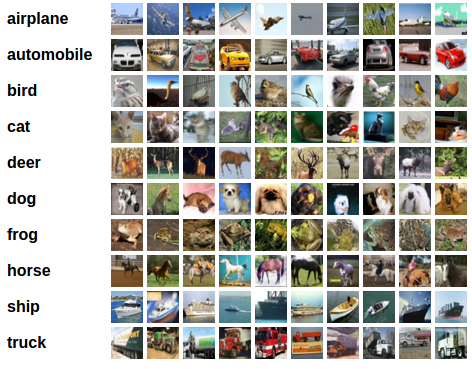

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading and manipulating images data with `torchvision`


The cell below downloads CIFAR-10 using `torchvision`.

***Note about using Torchvision***

torchvision is the PyTorch package built for vision tasks, so it provides:

- ready-made vision datasets like CIFAR10
- image transforms and augmentation utilities
- data-loading helpers that fit PyTorch training loops well


So in this notebook, torchvision is a natural choice because it gives you the dataset
 and the preprocessing tools in the same ecosystem.

HuggingFace datasets can also load CIFAR10,
but torchvision is the more standard PyTorch-first option for image.

In [4]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


After this, you'll have the CIFAR-10 training and testing splits downloaded into the `./data` directory.


Let's import NumPy, Pandas and look at our data:


In [5]:
import numpy as np
import pandas as pd

In [6]:

print('dataset type:',type(train_dataset_raw))
print()
print('dataset object:',dir(train_dataset_raw))


dataset type: <class 'torchvision.datasets.cifar.CIFAR10'>

dataset object: ['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_integrity', '_format_transform_repr', '_load_meta', '_repr_indent', 'base_folder', 'class_to_idx', 'classes', 'data', 'download', 'extra_repr', 'filename', 'meta', 'root', 'target_transform', 'targets', 'test_list', 'tgz_md5', 'train', 'train_list', 'transform', 'transforms', 'url']


### Data dimensions

CIFAR images are 3D per sample: (height, width, channels) = (32, 32, 3)

reshape(..., -1) flattens each image into 1 long vector: 32*32*3 = 3072 features

Result:
-   train_flat shape -> (num_train_samples, 3072)
-   test_flat shape  -> (num_test_samples, 3072)

### Feature Engineering: from Pixels --> Features

We need features for each image. The best way to construct *distinctive features* is to:

- Treat the image as a matrix of values. In this case, it's a 32x32 matrix
- In fact, each image is composed of 3 matrices: R,G,B

We take all that and build it into a feature.

### Matrix flattening:

When we flatten and stitch the 3 martices: Flattening turns them into one vector of length (32 \cdot 32 \cdot 3 = 3072).

We flatten the images (stitching all the RGB matrices together) and then we create a DataFrame where each row corresponds to an image and each column corresponds to a pixel feature. The last column is the label for each image.

**Final result:**
- Rows = individual images
- Columns = pixel features





In [7]:
class_names = train_dataset_raw.classes
print('class names:', class_names)

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# Flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

print('train_data.shape:', train_data.shape)
print('test_data.shape:', test_data.shape)
print()
print('train_data matrix head:' )
print(train_data.head())


class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train_data.shape: (50000, 3073)
test_data.shape: (10000, 3073)

train_data matrix head:
     0    1    2    3    4    5    6    7    8    9  ...  3063  3064  3065  \
0   59   62   63   43   46   45   50   48   43   68  ...   216   184   140   
1  154  177  187  126  137  136  105  104   95  102  ...   143   133   139   
2  255  255  255  253  253  253  253  253  253  253  ...    78    85    83   
3   28   25   10   37   34   19   38   35   20   42  ...    54    47    28   
4  170  180  198  168  178  196  177  185  203  183  ...    75    79    82   

   3066  3067  3068  3069  3070  3071  label  
0   151   118    84   123    92    72      6  
1   143   134   142   143   133   144      9  
2    79    85    83    80    86    84      9  
3    63    56    37    72    65    46      4  
4    71    75    78    73    77    80      1  

[5 rows x 3073 columns]


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


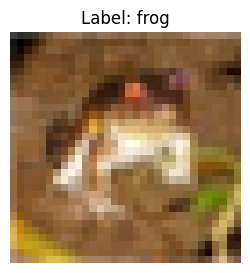

In [8]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 0
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

**Note** that CIFAR10 images are tiny, that's why we can't see the above image well.

Let's also load test data:


In [9]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**airplane** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.


### Didactic detour: Binary Classification as the simplest classification problem.

CIFAR-10 is inherently a multi-class dataset with 10 classes, but instructors often start with a binary subset (for example, class A vs class B) to teach core ideas first:

**Simpler objective and metrics:**
Binary classification is easier to reason about at the beginning (decision boundary, confusion matrix, precision/recall, threshold behavior).

**Easier debugging and intuition:**
You can inspect errors and understand model behavior faster with only 2 classes.

### Binary classification of categorical data: where Logistric regression shines!

For binary classification we use a **logistric regression**. Because 0 and 1 are actually dummy lables, not really numbers.

The 0 and 1 here are class codes, not quantities with real numeric meaning.

For binary classification, logistic regression is a standard choice because it models the probability of class 1:

- outputs a value in [0, 1]
- then uses a threshold (often 0.5) to choose class 0 vs class 1

**Two useful clarifications:**

You do not have to use logistic regression only.
**IMPORTANT NOTE!!**
*A neural network with one output neuron + sigmoid + binary cross-entropy is also a binary classifier.*

Even though labels are encoded as numbers, they are still categorical targets.
The model uses them as class indicators (Bernoulli targets), not as continuous values where distance matters like in regression.

### A Note on Logistic Regression
***Logistic regression is most commonly binary, but it also has multiclass versions:***

##### 1) Binary logistic regression
Two classes (0/1), sigmoid output.

##### 2) Multinomial logistic regression (softmax regression)
More than two classes, one model predicts class probabilities across all classes.

##### 3) One-vs-rest logistic regression
Train one binary classifier per class, then pick the highest score.

So logistic regression is for categorical targets in general, not only binary. Binary is just the simplest

### So let's extract data for airplane/ship classification and for cat/dog classification:

**Steps:**
- Step 1: Select 2 classes.

- Step 2: Filter the data to keep only those 2 classes.

- Step 3: Convert labels from class IDs to binary 0/1
--> this is to simplify the model's output. So it only has to predict a number, instead of a label.

**Note on terminology:**
General mapping:

X = input features --> pixel values.
y (or label) = target/output to predict --> 0's and 1's

- Step 4: Separate features and target. For this, we remove the `label` off the training data

`(label = y = the 0's and 1's we want to predict)`

In [10]:
# cat / dog classification

# gets the class IDs for cat and dog from the full 10-class list.
labels_to_train = [class_names.index('cat'), class_names.index('dog')]

#  Step 2: Filter the data to keep only those 2 classes
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
# we will assign 0 to 'cat' and 1 to 'dog'
# For that, we check if the label is equal to the index of 'dog' in class_names. If it is, we assign 1; otherwise, we assign 0.
# We do that for both train and test datasets. The resulting 'label' column will have 0 for 'cat' and 1 for 'dog'.
# In order for this trick to work we start from a subset of the dataset that contains only 'cat' and 'dog' classes, so the labels in that subset are either the index of 'cat' or the index of 'dog'.
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# divide data into features and target variable
# take the 'y' variables (labels) off the training data.
X_train_cat_dog = train_data_cat_dog.drop(columns=['label'])
y_train_cat_dog = train_data_cat_dog['label']
X_test_cat_dog = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog = test_data_cat_dog['label']


### Task 1.1. Write a neural network for binary classification

For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


### Task 1.1 Study Guide: Net for Binary Classification with MLP

**1. Big Picture**
For a neural network class, think of:

- **__init__:** declare parts of the model (layers, activations, dropout, etc.)

- **forward:** connect the parts to define how input flows to output#

**2. What __init__ should do (high level)**

- Store architecture hyperparameters (input size, hidden sizes)
- Define linear layers (example: input -> h1 -> h2 -> output)
- Define non-linear activations (often ReLU for hidden layers)
- Optionally define regularization layers (Dropout, BatchNorm)
- Define final output layer with 1 unit for binary classification (logit)

**Example:**

```
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_dim=3072, hidden1=256, hidden2=64):
        super().__init__()
        
        # Layers
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, 1)   # 1 logit for binary classification
        
        # Activations / regularization
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)
```

**3. What forward should do (high level)**

- Accept a batch x (shape usually [batch_size, 3072])
- Pass through hidden layers + activations
- Optionally apply dropout between hidden layers
- Return final output (typically raw logits for training)

**Example:**

```
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)

        logits = self.out(x)   # shape: [batch_size, 1]
        return logits

```

**Minimal mental template:**
```
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # define layers

    def forward(self, x):
        # layer -> activation -> layer -> activation -> output
        # return logits
        return logits
```

**4. Binary classification loss (defined outside of the class)**

Case 1) Binary setup with one output neuron:
  - model output: one logit per sample (shape [batch_size, 1] or [batch_size])
   - Loss: BCEWithLogitsLoss (binary cross entropy)
   - Targets: float 0/1

Case 2) Two-class multiclass setup with two output neurons:
- model output: two logits per sample (shape [batch_size, nbr_features] = [batch_size, 2])
- Loss: CrossEntropyLoss
- Targets: class indices 0/1 as integer (long)


**What BCEWithLogitsLoss means:**

- BCE = Binary Cross Entropy
- WithLogits = it expects raw logits and applies sigmoid internally in a numerically stable way
- So if you use BCEWithLogitsLoss, do not apply sigmoid before computing loss.


**5. Predictions:**
```
probs = torch.sigmoid(logits)           # [0, 1]
preds = (probs >= 0.5).int()            # 0 or 1
```



### OBS Binary Logistic Regression <> Feed Forward MLP!!!

 Logistic regression is basically the simplest possible neural classifier.

In Pytorch:

```
import torch
import torch.nn as nn

class LogisticNet(nn.Module):
    def __init__(self, input_dim=3072):
        super().__init__()
        self.out = nn.Linear(input_dim, 1)

    def forward(self, x):
        logits = self.out(x)
        return logits
```

Then train with **BCEWithLogitsLoss.**


### Quick Decision Tree: Choosing Hidden Sizes and Dropout (Binary CIFAR Baseline)

#### **What we are looking for:**

- **Bigger hidden layers** = more capacity, more risk of overfitting
Why: they can learn more complex patterns, but they can also memorize noise in the training set.

- **Smaller hidden layers** = less capacity, more risk of underfitting
Why: they are simpler and easier to train, but they may be too weak to capture the real structure in the data.

**Practical rule of thumb**
- If the model is too small, it underfits, so increase hidden sizes or reduce regularization.
- If the model is too large, it overfits, so use dropout, batch norm, weight decay, early stopping, or smaller layers.


#### **Extra tricks to control this tradeoff**

**Dropout:** randomly turns off some neurons during training.
Why it helps: it prevents the network from relying too much on specific units and reduces overfitting.

**Batch normalization:*** normalizes the output of the activations inside the network.
Why it helps: it makes training more stable and often faster, and it can also give a mild regularization effect.

**Weight decay / L2 regularization:** adds a penalty for large weights.
Why it helps: it discourages overly complex decision boundaries and improves generalization.

**Early stopping:** stop training when validation performance stops improving.
Why it helps: it prevents the model from continuing to fit noise after it has already learned the useful patterns.

**Data augmentation:** create altered versions of training images, such as flips or crops.
Why it helps: it effectively increases the training set and makes the model more robust.


##### Use this to pick a first model fast, then tune.

1. Start Simple (Good Default): we want: capacity speed and generalization
 - Architecture: 3072 -> 256 -> 64 -> 1 (arbitrary neurons, textbook)
- alternatively: input size -> input size//2 -> inputsize//4 --> output size
- Activation: ReLU
- Dropout: 0.2
- Loss: BCEWithLogitsLoss
- Optimizer: Adam(lr=1e-3)

```Net(input_dim=3072, hidden1=256, hidden2=64, dropout=0.2)```


2. If Training Accuracy Is Low (Underfitting)
Symptoms:

Train and val accuracy both low
Loss plateaus early
Try:

- Increase width: 256 -> 512, 64 -> 128
- Add one extra hidden layer
- Reduce dropout (0.2 -> 0.1)
- Train longer (more epochs)

3. If Train High but Val/Test Low (Overfitting)
Symptoms:

Train accuracy keeps rising
Val/test stalls or drops
Try:

- Increase dropout (0.2 -> 0.3/0.4)
- Add weight decay (L2): Adam(..., weight_decay=1e-4)
- Reduce model size
- Use early stopping

```optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)```

4. Learning Rate Tuning Rule
Loss noisy/diverging: lower LR (1e-3 -> 3e-4)
Loss decreases very slowly: increase LR slightly (1e-3 -> 2e-3) or use scheduler

```optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)```

### Activation functions

**Summary**
- "relu" -> nn.ReLU # Default for hidden layers in deep nets (MLP/CNN), especially for image tasks like CIFAR-10.
- "tanh" -> nn.Tanh # Useful in smaller/shallower nets when zero-centered activations can help training dynamics.
- "sigmoid" -> nn.Sigmoid # Common at binary output heads for probabilities; less common in hidden layers due to vanishing gradients.



### Activation Functions (short)

#### Why activations matter
Without activation functions, stacked linear layers are still just one linear function. Activations add non-linearity so networks can learn complex decision boundaries.

#### 1) `ReLU` (`nn.ReLU`)
**Formula:** `f(x) = max(0, x)`

**When it is used**
- Default choice for hidden layers in MLPs and CNNs.
- Common in vision tasks like CIFAR-10.
- Good first baseline in almost any deep network.

**Pros**
- Very fast and simple computation.
- Helps gradient flow for positive inputs (less vanishing gradient than sigmoid/tanh).
- Produces sparse activations (many zeros), which can improve efficiency and sometimes generalization.
- Usually converges faster in practice.

**Cons**
- "Dying ReLU" problem: neurons can get stuck outputting zero if inputs are mostly negative.
- Not zero-centered outputs.
- Unbounded on positive side, which can sometimes lead to unstable activations if training is poorly tuned.

**Quick Points**
- If asked "default hidden activation?": usually ReLU.
- If asked "main failure mode?": dying ReLU.
- If asked "fixes?": lower LR, better init, or try LeakyReLU/ELU/GELU.

#### 2) `Tanh` (`nn.Tanh`)
**Formula:** `f(x) = (e^x - e^{-x}) / (e^x + e^{-x})`, output range `[-1, 1]`

**When it is used**
- Hidden layers in smaller or older architectures.
- Situations where zero-centered activations are helpful.
- Some recurrent or control-style models where bounded outputs are useful.

**Pros**
- Zero-centered output, which can make optimization smoother than sigmoid in some cases.
- Bounded outputs can stabilize activations.
- Often better than sigmoid in hidden layers.

**Cons**
- Saturates at large positive/negative values, causing vanishing gradients.
- Usually slower training than ReLU in deep networks.
- Can struggle in very deep feed-forward nets without careful setup.

**Quick Points**
- Better than sigmoid for hidden layers because it is zero-centered.
- Still suffers from vanishing gradients due to saturation.
- Less common than ReLU in modern deep vision models.

#### 3) `Sigmoid` (`nn.Sigmoid`)
**Formula:** `f(x) = 1 / (1 + e^{-x})`, output range `[0, 1]`

**When it is used**
- Binary classification output heads when interpreting probability of class 1.
- Multi-label classification outputs (one sigmoid per class).
- Gating mechanisms (for example, in LSTM internals).

**Pros**
- Natural probability-like output in `[0,1]`.
- Easy interpretation for binary outcomes.
- Useful when each output dimension is an independent yes/no.

**Cons**
- Strong vanishing gradient in saturated regions.
- Not zero-centered output.
- Typically poor choice for deep hidden layers today.
- Can train slowly compared with ReLU-based hidden layers.

**Quick points**
- Great for binary output layer, not great for deep hidden layers.
- Pair with `BCEWithLogitsLoss` by passing logits directly (better numerical stability than applying sigmoid manually first).
- For multi-class single-label classification, use softmax/cross-entropy instead.

#### Quick "Which one should I pick?" for CIFAR-style MLP
- Hidden layers: start with **ReLU**.
- Binary output: use **1 logit + `BCEWithLogitsLoss`** (internally handles sigmoid).
- Multi-class single-label output: use **logits + `CrossEntropyLoss`** (internally handles softmax).

#### High-value  comparisons
- **ReLU vs Tanh**: ReLU usually trains faster and scales better to deeper nets; tanh is zero-centered but saturates.
- **Tanh vs Sigmoid**: Tanh is generally preferred in hidden layers because zero-centered outputs improve optimization.
- **Sigmoid vs Softmax**: Sigmoid treats each class independently (multi-label). Softmax enforces probabilities summing to 1 (single-label multi-class).

#### Common mistakes (frequent  traps)
- Using sigmoid in every hidden layer of a deep net and wondering why training is slow.
- Applying sigmoid before `BCEWithLogitsLoss` (double sigmoid issue).
- Applying softmax before `CrossEntropyLoss` in PyTorch (usually unnecessary and less stable).
- Using sigmoid output for a single-label 10-class task instead of softmax/logits with CE.

#### One-line memory hook
- **ReLU**: best default hidden activation.
- **Tanh**: zero-centered but saturates.
- **Sigmoid**: binary probability output, rarely hidden activation in modern deep nets.



In [11]:
import torch
import torch.nn as nn


class Net(nn.Module):
    """
    Flexible MLP for binary or 2-class classification on flattened CIFAR-like inputs.

    Main idea:
    - Control architecture from outside the class (for experiments/grid search).
    - No hardcoded layer count or hidden size.
    - Optional dropout and batch normalization.
    """

    def __init__(
        self,
        input_dim=3072,              # 32*32*3 for flattened CIFAR image
        hidden_dims=(256, 64),       # tuple/list with hidden layer sizes; can be any length
        activation="relu",           # "relu", "tanh", or "sigmoid"
        dropout=0.0,                 # dropout probability (0.0 means disabled)
        use_batchnorm=False,         # whether to add BatchNorm1d after each Linear hidden layer
        output_dim=1                 # 1 for BCEWithLogitsLoss, 2 for CrossEntropyLoss
    ):
        super().__init__()

        # ------------------------------------------------------------
        # 1) Validate and prepare activation choice
        # ------------------------------------------------------------
        activation = activation.lower()  # Normalizes input like "ReLU" or "RELU" to "relu".
        # ------------------------------------------------------------
        # Activation functions
        #
        # Summary
        # - "relu" -> nn.ReLU # Default for hidden layers in deep nets (MLP/CNN), especially for image tasks like CIFAR-10.
        # - "tanh" -> nn.Tanh # Useful in smaller/shallower nets when zero-centered activations can help training dynamics.
        # - "sigmoid" -> nn.Sigmoid # Common at binary output heads for probabilities; less common in hidden layers due to vanishing gradients.
        # ------------------------------------------------------------
        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid,
        }
        if activation not in activation_map:
            raise ValueError(
                f"Unsupported activation '{activation}'. "
                f"Use one of: {list(activation_map.keys())}"
            )

        # ------------------------------------------------------------
        # 2) Build the network dynamically
        # ------------------------------------------------------------
        # We create a Python list of layers, then pack them into nn.Sequential.
        # This is what makes depth flexible (depends on hidden_dims length).
        layers = []

        # Flatten ensures input can be [batch_size, 32, 32, 3] or similar,
        # and converts it to [batch_size, 3072].
        layers.append(nn.Flatten())

        prev_dim = input_dim

        # For each hidden layer size h:
        # Linear(prev_dim -> h)
        # [optional] BatchNorm1d(h)
        # Activation
        # [optional] Dropout
        for h in hidden_dims:
            # Fully connected transform
            layers.append(nn.Linear(prev_dim, h))

            # BatchNorm stabilizes hidden activations during training
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            # Non-linearity lets network learn non-linear decision boundaries
            layers.append(activation_map[activation]())

            # Dropout regularization to reduce overfitting
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))

            prev_dim = h

        # Final output layer:
        # - output_dim=1: one logit (binary setup with BCEWithLogitsLoss)
        # - output_dim=2: two logits (2-class setup with CrossEntropyLoss)
        layers.append(nn.Linear(prev_dim, output_dim))

        # Store as one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass:
        x -> flatten -> hidden blocks -> output logits
        """
        logits = self.model(x)
        return logits

And create a network:

In [12]:
# -----------------------------------------
# A) Binary setup (recommended for your task)
# one output logit + BCEWithLogitsLoss
# -----------------------------------------
net = Net(
    input_dim=3072,
    hidden_dims=(256, 64),
    activation="relu",
    dropout=0.2,
    use_batchnorm=False,
    output_dim=1
)

# criterion = nn.BCEWithLogitsLoss()
# target y should be float 0/1 (shape [batch_size, 1] or [batch_size])


# -----------------------------------------
# B) Two-logit setup (alternative)
# two output logits + CrossEntropyLoss
# -----------------------------------------
'''
net_ce = Net(
    input_dim=3072,
    hidden_dims=(256, 64),
    activation="relu",
    dropout=0.2,
    use_batchnorm=True,
    output_dim=2
)

# criterion = nn.CrossEntropyLoss()
# target y should be long class indices 0/1 (shape [batch_size])
'''

'\nnet_ce = Net(\n    input_dim=3072,\n    hidden_dims=(256, 64),\n    activation="relu",\n    dropout=0.2,\n    use_batchnorm=True,\n    output_dim=2\n)\n\n# criterion = nn.CrossEntropyLoss()\n# target y should be long class indices 0/1 (shape [batch_size])\n'

### Task 1.2. Define a train function.


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


### Concept: Epoch vs Batches

**Epoch**
An epoch is one full pass through the entire training dataset.

- During one epoch, the model sees every training sample once (typically in shuffled order).
- Number of minibatches per epoch is approximately:
- num_batches = ceil(N / B)


**Relationship**

Training loop hierarchy:
- For each epoch
- Iterate through all minibatches
- For each minibatch, compute loss, backpropagate, and update parameters

**Minibatch**
A minibatch is a small subset of the training dataset processed in one forward/backward pass.

- If dataset size is N and batch size is B, each update uses B samples.
- One minibatch produces one gradient estimate and usually one optimizer step.
- Why minibatches:
    - Fit data into GPU memory
    - Reduce gradient noise compared to single-sample updates
    - Use GPU parallelism efficiently

### Concept: Types of Optimizers (Short Guide)

- `SGD`: simple and fast baseline. Good control, but can be slower to converge.
- `SGD + Momentum`: adds velocity to reduce zig-zag updates and usually trains faster than plain SGD.
- `Adam`: adaptive learning rates per parameter (`momentum + RMS` idea). Usually the easiest strong default.
- `AdamW`: Adam with decoupled weight decay. Common modern default for better regularization behavior.

Practical rule: start with `Adam/AdamW` for quick progress; try `SGD + Momentum` when tuning for final performance.


### Concept: What is `DataLoader` and why do we need it?

`DataLoader` is a PyTorch utility that turns a dataset into mini-batches and feeds them to the training loop.

Main advantages:
- Automatic batching (`batch_size`)
- Shuffling each epoch (`shuffle=True`) for better generalization
- Efficient data loading with workers (`num_workers`)
- Clean, consistent iteration (`for X_batch, y_batch in loader`)

In short: `Dataset` defines what one sample is; `DataLoader` defines how samples are delivered efficiently during training.


In [13]:
if 'train' not in globals():
    def train(model, dataloader, criterion, optimizer, num_epoch, device=None, show_progress=True):
        # -----------------------------
        # 1) Pick computation device
        # -----------------------------
        # If user did not pass a device, use GPU when available, otherwise CPU.
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Move model parameters to the selected device once before training.
        model = model.to(device)

        # We store one value per epoch: average training loss over all batches.
        history = []

        # Try to use a tqdm progress bar if available; otherwise fallback to plain range.
        use_tqdm = False
        epoch_iter = range(num_epoch)
        if show_progress:
            try:
                from tqdm.auto import tqdm
                epoch_iter = tqdm(range(num_epoch), desc='Training', leave=True)
                use_tqdm = True
            except Exception:
                epoch_iter = range(num_epoch)

        # -----------------------------
        # 2) Epoch loop
        # -----------------------------
        # One epoch = one full pass over the whole training dataloader.
        for epoch in epoch_iter:
            # `train()` enables training behavior for layers like Dropout/BatchNorm.
            model.train()

            # Running counters for average epoch loss.
            epoch_loss = 0.0
            n_batches = 0

            # -----------------------------
            # 3) Mini-batch loop
            # -----------------------------
            for X_batch, y_batch in dataloader:
                # Put data on the same device as the model and cast to float
                # (needed for BCEWithLogitsLoss targets and dense features).
                X_batch = X_batch.to(device).float()
                y_batch = y_batch.to(device).float()

                # BCEWithLogitsLoss needs matching shapes: logits and targets.
                # If labels are [B], convert to [B, 1].
                if y_batch.ndim == 1:
                    y_batch = y_batch.unsqueeze(1)

                # Standard training step:
                # zero old gradients -> forward -> loss -> backward -> optimizer step.
                optimizer.zero_grad()
                logits = model(X_batch)

                # Ensure logits are also [B, 1] for binary setup.
                if logits.ndim == 1:
                    logits = logits.unsqueeze(1)

                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

                # Accumulate batch loss to compute epoch average later.
                epoch_loss += loss.item()
                n_batches += 1

            # Save average loss for this epoch.
            avg_loss = epoch_loss / max(n_batches, 1)
            history.append(avg_loss)

            # Show live loss updates during training.
            if show_progress and use_tqdm:
                epoch_iter.set_postfix(loss=f'{avg_loss:.4f}')
            elif show_progress:
                print(f'Epoch {epoch + 1}/{num_epoch} - loss: {avg_loss:.4f}')

        # Return the trained model and loss curve for plotting/analysis.
        return model, history

And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


In [14]:
import torch
import torch.nn as nn
import tqdm
from tqdm.auto import tqdm

# model
net = Net(hidden_dims=(256, 64), activation="relu", dropout=0.2, use_batchnorm=False, output_dim=1)

# loss / optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

# dataloader
# Build a real PyTorch dataset from the cat/dog feature and label tables.
if 'X_train_cat_dog' not in globals() or 'y_train_cat_dog' not in globals():
    raise NameError("Run the cat/dog data-prep cell first (it defines X_train_cat_dog and y_train_cat_dog).")

X_train_tensor = torch.tensor(X_train_cat_dog.values, dtype=torch.float32)  # PyTorch models/operators work on tensors, so tabular arrays must be converted before training.
y_train_tensor = torch.tensor(y_train_cat_dog.values, dtype=torch.float32)  # Labels are also converted to tensors so loss functions can compute gradients consistently.

binary_train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)  # TensorDataset pairs feature/label tensors and lets DataLoader batch them together.
train_loader = torch.utils.data.DataLoader(binary_train_dataset, batch_size=64, shuffle=True)

# Explicitly define train function here to ensure correct behavior for BCEWithLogitsLoss
def train_binary(model, dataloader, criterion, optimizer, num_epoch, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    history = {'train_loss': []}

    for _ in tqdm(range(num_epoch), desc='Training binary'):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            # Ensure y_batch is [batch_size, 1] and float for BCEWithLogitsLoss
            y_batch = y_batch.to(device).float().unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        history['train_loss'].append(running_loss / max(num_batches, 1))

    return model, history

# run training
net, history = train_binary(net, train_loader, criterion, optimizer, num_epoch=60)


Training binary:   0%|          | 0/60 [00:00<?, ?it/s]

### Task 1.3. Write a code for model evaluation


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [15]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    model.eval()  # switch to evaluation mode (disables training behavior like Dropout updates)
    device = next(model.parameters()).device

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch (logits)
            y_pred = model(X_batch)

            # calculate loss function
            y_true = y_batch.float().unsqueeze(1)
            loss = criterion(y_pred, y_true)
            losses.append(loss.item())

        # convert outputs of your network into class number (0/1)
        y_pred = (torch.sigmoid(y_pred) >= 0.5).long().squeeze(1).cpu().tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)  # append this batch predictions to the full prediction list
        y_true_list.extend(y_batch.long().cpu().tolist())  # append this batch ground-truth labels

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))  # fraction of correct predictions over all test samples

    return np.mean(losses), accuracy  # return average loss and accuracy for the whole loader


### Quick Note: Why Tensors?

- We use **tensors** because PyTorch models, losses, and autograd are built to work with tensors.
- Tensors can run on **GPU** directly and support automatic gradient tracking (`requires_grad`) for training.
- NumPy arrays are great for general numeric work, but they do not natively provide PyTorch autograd or seamless model/device integration.


And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [16]:
if 'X_test_cat_dog' not in globals() or 'y_test_cat_dog' not in globals():
    raise NameError("Run the cat/dog data-prep cell first (it defines X_test_cat_dog and y_test_cat_dog).")

X_test_tensor = torch.tensor(X_test_cat_dog.values, dtype=torch.float32)  # Evaluation also expects tensors because the model forward pass is tensor-based.
y_test_tensor = torch.tensor(y_test_cat_dog.values, dtype=torch.float32)  # Keep label type aligned with BCE-style evaluation pipeline.

test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)  # Same idea: wraps tensors into a dataset interface used by DataLoader.
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

evaluate(net, test_loader, criterion)


(np.float64(0.6931487396359444), np.float64(0.5))

### Task 1.4. Train the neural network to classify airplane/ship images


Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


Training Binary Classification:   0%|          | 0/100 [00:00<?, ?it/s]

Baseline (ReLU) -> test_loss: 0.7525, test_acc: 0.8050


Training Binary Classification:   0%|          | 0/100 [00:00<?, ?it/s]

TANH -> test_loss: 3.3741, test_acc: 0.5300


Training Binary Classification:   0%|          | 0/100 [00:00<?, ?it/s]

SIGMOID -> test_loss: 0.5091, test_acc: 0.7915


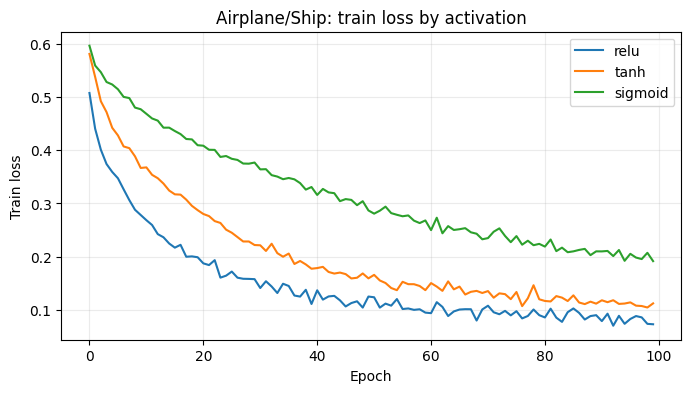

Saved plot: plots/airplane_ship_train_loss_by_activation.png
Best activation by test accuracy: relu (acc=0.8050)


In [17]:
# This cell handles the setup, training, and evaluation for binary classification tasks (specifically airplane/ship).
# It defines `train` and `evaluate` functions locally to ensure they use the correct target reshaping for BCEWithLogitsLoss
# and then runs experiments to compare different activation functions.

import matplotlib.pyplot as plt
from pathlib import Path
import tqdm
from tqdm.auto import tqdm

def train(model, dataloader, criterion, optimizer, num_epoch, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    history = {'train_loss': []}

    # Use tqdm for a progress bar for epochs
    epoch_iter = tqdm(range(num_epoch), desc='Training Binary Classification')

    for epoch in epoch_iter:
        model.train()
        running_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float().unsqueeze(1) # Ensure y_batch is [batch_size, 1]

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        avg_loss = running_loss / max(num_batches, 1)
        history['train_loss'].append(avg_loss)
        epoch_iter.set_postfix(loss=f'{avg_loss:.4f}') # Update progress bar with current loss

    return model, history

def evaluate(model, loader, criterion):
    model.eval()
    device = next(model.parameters()).device
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device) # Keep y_batch as is for now, will be unsqueezed for loss

        with torch.no_grad():
            logits = model(X_batch)
            # Ensure target for loss is [batch_size, 1] if output_dim=1
            loss = criterion(logits, y_batch.float().unsqueeze(1))
            losses.append(loss.item())

        y_pred = (torch.sigmoid(logits) >= 0.5).long().squeeze(1).cpu().tolist()
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.long().cpu().tolist())

    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

    return np.mean(losses), accuracy

# 1) Build airplane/ship binary subset from full CIFAR dataframe
labels_to_train = [class_names.index('airplane'), class_names.index('ship')]

train_data_airplane_ship = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_airplane_ship = test_data[test_data['label'].isin(labels_to_train)].copy()

# Map labels to 0/1: airplane -> 0, ship -> 1
train_data_airplane_ship['label'] = (train_data_airplane_ship['label'] == class_names.index('ship')).astype(int)
test_data_airplane_ship['label'] = (test_data_airplane_ship['label'] == class_names.index('ship')).astype(int)

X_train_airplane_ship = train_data_airplane_ship.drop(columns=['label'])
y_train_airplane_ship = train_data_airplane_ship['label']
X_test_airplane_ship = test_data_airplane_ship.drop(columns=['label'])
y_test_airplane_ship = test_data_airplane_ship['label']

# 2) Convert to tensors and create loaders
X_train_tensor = torch.tensor(X_train_airplane_ship.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_airplane_ship.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_airplane_ship.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_airplane_ship.values, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3) Baseline run (ReLU)
criterion = nn.BCEWithLogitsLoss()

net = Net(
    input_dim=3072,
    hidden_dims=(512, 256, 128),
    activation='relu',
    dropout=0.1,
    use_batchnorm=True,
    output_dim=1
)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

net, history_relu = train(net, train_loader, criterion, optimizer, num_epoch=100)
baseline_test_loss, baseline_test_acc = evaluate(net, test_loader, criterion)
print(f"Baseline (ReLU) -> test_loss: {baseline_test_loss:.4f}, test_acc: {baseline_test_acc:.4f}")

# 4) Compare hidden-layer activations with same hyperparameters
histories = {'relu': history_relu}
results = {'relu': (baseline_test_loss, baseline_test_acc)}

for act in ['tanh', 'sigmoid']:
    model = Net(
        input_dim=3072,
        hidden_dims=(512, 256, 128),
        activation=act,
        dropout=0.1,
        use_batchnorm=True,
        output_dim=1
    )
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    model, h = train(model, train_loader, criterion, optim, num_epoch=100)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    histories[act] = h
    results[act] = (test_loss, test_acc)
    print(f"{act.upper()} -> test_loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

# Make plotting robust to both history formats:
# - list from train(...) that returns [loss_1, loss_2, ...]
# - dict from train(...) that returns {'train_loss': [...]}.
def _extract_train_loss(history_obj):
    if isinstance(history_obj, dict):
        return history_obj['train_loss']
    return history_obj

# 5) Plot loss curves for the three activations
output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
airplane_ship_plot_path = output_dir / 'airplane_ship_train_loss_by_activation.png'

plt.figure(figsize=(8, 4))
for act in ['relu', 'tanh', 'sigmoid']:
    plt.plot(_extract_train_loss(histories[act]), label=act)
plt.title('Airplane/Ship: train loss by activation')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(airplane_ship_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {airplane_ship_plot_path}")

# 6) Pick best activation by test accuracy
best_act = max(results, key=lambda k: results[k][1])
print(f"Best activation by test accuracy: {best_act} (acc={results[best_act][1]:.4f})")

### Task 1.5. Train the neural network to classify cat/dog images


### Task 1.4.1 Further Fine-tuning for Airplane/Ship Classification

Let's experiment with a wider network, adjusted dropout, a smaller learning rate, larger batch size, and more epochs for the Sigmoid activation, as it showed the best performance previously.


--- Running optimized experiment for Sigmoid activation ---
Hidden Dims: (1024, 512, 256), Dropout: 0.05, LR: 0.0005, Batch Size: 128, Epochs: 150


Training Binary Classification:   0%|          | 0/150 [00:00<?, ?it/s]

Optimized Sigmoid -> test_loss: 0.6314, test_acc: 0.8065


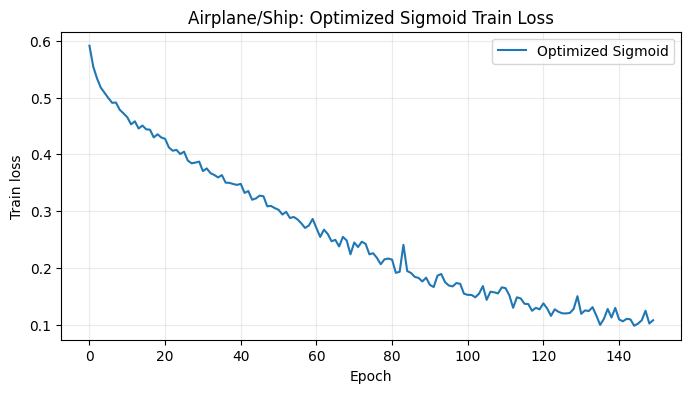

Saved plot: plots/airplane_ship_optimized_sigmoid_train_loss.png


In [18]:
# Fine-tuning with Sigmoid activation
criterion = nn.BCEWithLogitsLoss()

# New hyperparameters
OPTIMIZED_HIDDEN_DIMS = (1024, 512, 256)
OPTIMIZED_DROPOUT = 0.05
OPTIMIZED_LR = 5e-4
OPTIMIZED_BATCH_SIZE = 128
OPTIMIZED_EPOCHS = 150

print(f"\n--- Running optimized experiment for Sigmoid activation ---")
print(f"Hidden Dims: {OPTIMIZED_HIDDEN_DIMS}, Dropout: {OPTIMIZED_DROPOUT}, LR: {OPTIMIZED_LR}, Batch Size: {OPTIMIZED_BATCH_SIZE}, Epochs: {OPTIMIZED_EPOCHS}")

# Re-create train_loader with optimized batch size
train_loader_optimized = torch.utils.data.DataLoader(train_dataset, batch_size=OPTIMIZED_BATCH_SIZE, shuffle=True)
test_loader_optimized = torch.utils.data.DataLoader(test_dataset, batch_size=OPTIMIZED_BATCH_SIZE, shuffle=False)

model_optimized_sigmoid = Net(
    input_dim=3072,
    hidden_dims=OPTIMIZED_HIDDEN_DIMS,
    activation='sigmoid',
    dropout=OPTIMIZED_DROPOUT,
    use_batchnorm=True,
    output_dim=1
)
optimizer_optimized_sigmoid = torch.optim.Adam(model_optimized_sigmoid.parameters(), lr=OPTIMIZED_LR, weight_decay=1e-4)

model_optimized_sigmoid, history_optimized_sigmoid = train(model_optimized_sigmoid, train_loader_optimized, criterion, optimizer_optimized_sigmoid, num_epoch=OPTIMIZED_EPOCHS)

optimized_test_loss, optimized_test_acc = evaluate(model_optimized_sigmoid, test_loader_optimized, criterion)
print(f"Optimized Sigmoid -> test_loss: {optimized_test_loss:.4f}, test_acc: {optimized_test_acc:.4f}")

# Plotting the optimized sigmoid loss curve
output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
optimized_sigmoid_plot_path = output_dir / 'airplane_ship_optimized_sigmoid_train_loss.png'

plt.figure(figsize=(8, 4))
plt.plot(_extract_train_loss(history_optimized_sigmoid), label='Optimized Sigmoid')
plt.title('Airplane/Ship: Optimized Sigmoid Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(optimized_sigmoid_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {optimized_sigmoid_plot_path}")

### Task 1.4.2 Further Fine-tuning for Airplane/Ship Classification (Attempt 2)

Reverting to the previous best architecture and increasing dropout.


--- Running optimized experiment for Sigmoid activation (Attempt 2) ---
Hidden Dims: (512, 256, 128), Dropout: 0.1, LR: 0.001, Batch Size: 64, Epochs: 250


Training Binary Classification:   0%|          | 0/250 [00:00<?, ?it/s]

Optimized Sigmoid (Attempt 2) -> test_loss: 0.5939, test_acc: 0.7935


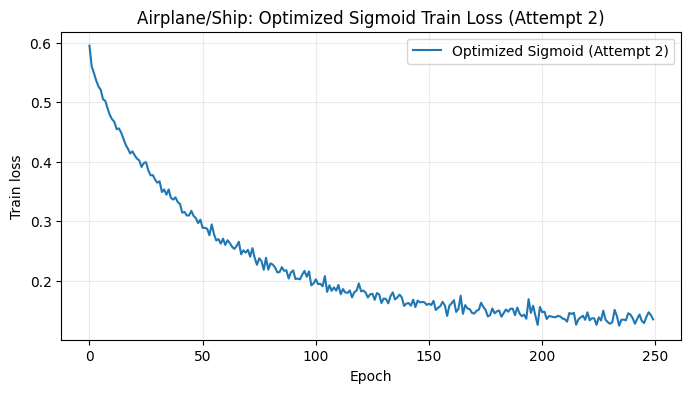

Saved plot: plots/airplane_ship_optimized_sigmoid_train_loss_attempt2.png


In [19]:
# Fine-tuning with Sigmoid activation (Attempt 2)
criterion = nn.BCEWithLogitsLoss()

# Hyperparameters for Attempt 2
OPTIMIZED_HIDDEN_DIMS_2 = (512, 256, 128) # Reverting to the architecture that gave 0.788 acc
OPTIMIZED_DROPOUT_2 = 0.1                  # Reverting to 0.1 dropout
OPTIMIZED_LR_2 = 1e-3
OPTIMIZED_BATCH_SIZE_2 = 64
OPTIMIZED_EPOCHS_2 = 250                   # Increased epochs to 250

print(f"\n--- Running optimized experiment for Sigmoid activation (Attempt 2) ---")
print(f"Hidden Dims: {OPTIMIZED_HIDDEN_DIMS_2}, Dropout: {OPTIMIZED_DROPOUT_2}, LR: {OPTIMIZED_LR_2}, Batch Size: {OPTIMIZED_BATCH_SIZE_2}, Epochs: {OPTIMIZED_EPOCHS_2}")

# Re-create train_loader with optimized batch size
train_loader_optimized_2 = torch.utils.data.DataLoader(train_dataset, batch_size=OPTIMIZED_BATCH_SIZE_2, shuffle=True)
test_loader_optimized_2 = torch.utils.data.DataLoader(test_dataset, batch_size=OPTIMIZED_BATCH_SIZE_2, shuffle=False)

model_optimized_sigmoid_2 = Net(
    input_dim=3072,
    hidden_dims=OPTIMIZED_HIDDEN_DIMS_2,
    activation='sigmoid',
    dropout=OPTIMIZED_DROPOUT_2,
    use_batchnorm=True,
    output_dim=1
)
optimizer_optimized_sigmoid_2 = torch.optim.Adam(model_optimized_sigmoid_2.parameters(), lr=OPTIMIZED_LR_2, weight_decay=1e-4)

model_optimized_sigmoid_2, history_optimized_sigmoid_2 = train(model_optimized_sigmoid_2, train_loader_optimized_2, criterion, optimizer_optimized_sigmoid_2, num_epoch=OPTIMIZED_EPOCHS_2)

optimized_test_loss_2, optimized_test_acc_2 = evaluate(model_optimized_sigmoid_2, test_loader_optimized_2, criterion)
print(f"Optimized Sigmoid (Attempt 2) -> test_loss: {optimized_test_loss_2:.4f}, test_acc: {optimized_test_acc_2:.4f}")

# Plotting the optimized sigmoid loss curve
output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
optimized_sigmoid_plot_path_2 = output_dir / 'airplane_ship_optimized_sigmoid_train_loss_attempt2.png'

plt.figure(figsize=(8, 4))
plt.plot(_extract_train_loss(history_optimized_sigmoid_2), label='Optimized Sigmoid (Attempt 2)')
plt.title('Airplane/Ship: Optimized Sigmoid Train Loss (Attempt 2)')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(optimized_sigmoid_plot_path_2, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {optimized_sigmoid_plot_path_2}")

### Practical Boosters for Image Classification:

To push accuracy further, especially in image tasks, consider:

- **RandAugment**: A data augmentation technique that applies a random set of image transformations to improve model robustness.
- **Mixup/CutMix**: Data augmentation strategies that combine multiple images and their labels to create new training examples, reducing overfitting and improving generalization.
- **Strong LR scheduling**: Advanced learning rate schedules (e.g., cosine annealing, one-cycle policy) that can help the model converge faster and to a better optimum.

Now that you have optimized your network for airplane/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the airplane/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the airplane/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.


In [20]:
# first define new dataloaders for train/test on train_data_cat_dog/test_data_cat_dog
X_train_tensor = torch.tensor(X_train_cat_dog.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_cat_dog.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_cat_dog.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_cat_dog.values, dtype=torch.float32)

train_dataset_cat_dog = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_cat_dog = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader_cat_dog = torch.utils.data.DataLoader(train_dataset_cat_dog, batch_size=64, shuffle=True)
test_loader_cat_dog = torch.utils.data.DataLoader(test_dataset_cat_dog, batch_size=64, shuffle=False)


In [21]:
# Train and evaluate on cat/dog
criterion = nn.BCEWithLogitsLoss()

net_cat_dog = Net(
    input_dim=3072,
    hidden_dims=(512, 128),
    activation='relu',
    dropout=0.3,
    use_batchnorm=True,
    output_dim=1
)
optimizer = torch.optim.Adam(net_cat_dog.parameters(), lr=1e-3, weight_decay=1e-4)

net_cat_dog, history_cat_dog = train(net_cat_dog, train_loader_cat_dog, criterion, optimizer, num_epoch=40)
cat_dog_test_loss, cat_dog_test_acc = evaluate(net_cat_dog, test_loader_cat_dog, criterion)
print(f"Cat/Dog -> test_loss: {cat_dog_test_loss:.4f}, test_acc: {cat_dog_test_acc:.4f}")


Training Binary Classification:   0%|          | 0/40 [00:00<?, ?it/s]

Cat/Dog -> test_loss: 0.8092, test_acc: 0.6490


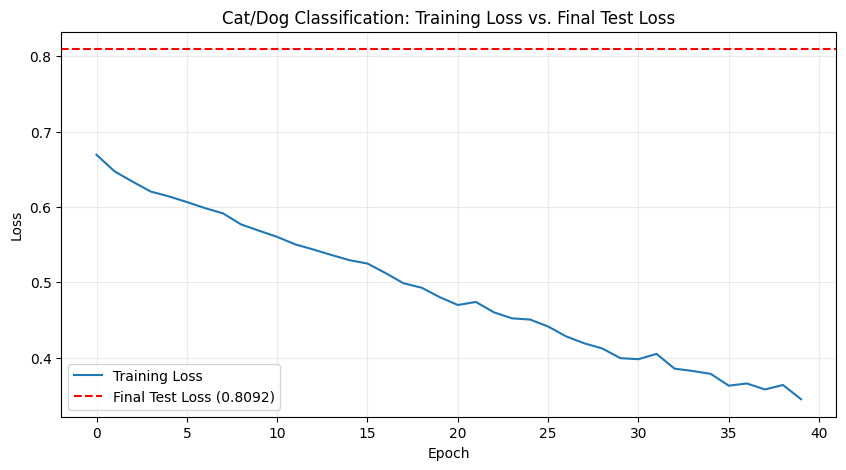

Saved plot: plots/cat_dog_train_vs_test_loss.png


In [22]:
import matplotlib.pyplot as plt
from pathlib import Path

# Helper function to extract train loss, robust to list or dict format
def _extract_train_loss(history_obj):
    if isinstance(history_obj, dict):
        return history_obj['train_loss']
    return history_obj

# Plotting training loss vs. test loss for Cat/Dog classification
output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
cat_dog_plot_path = output_dir / 'cat_dog_train_vs_test_loss.png'

plt.figure(figsize=(10, 5))
plt.plot(_extract_train_loss(history_cat_dog), label='Training Loss')
plt.axhline(y=cat_dog_test_loss, color='r', linestyle='--', label=f'Final Test Loss ({cat_dog_test_loss:.4f})')
plt.title('Cat/Dog Classification: Training Loss vs. Final Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(cat_dog_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {cat_dog_plot_path}")

### Summary of Experiment Results

Here's a comprehensive summary of the test loss and accuracy for all the classification tasks and models evaluated in this notebook. This table will help us compare the performance across different architectures and hyperparameters, and identify which approaches were most effective.

### Summary of Experimental Findings and Answers to Questions

Based on the various experiments conducted for binary and multi-class classification on the CIFAR-10 dataset, here are the observations and answers to your questions, derived directly from the recorded results.

---

In [23]:
import pandas as pd

# Initialize a list to store results
summary_results = []

# 1. Cat/Dog Binary Classification (Initial Run)
if 'cat_dog_test_loss' in globals() and 'cat_dog_test_acc' in globals():
    summary_results.append({
        'Task': 'Cat/Dog Binary (Initial)',
        'Model': 'Net (512, 128, ReLU, BatchNorm, Dropout 0.3)',
        'Test Loss': cat_dog_test_loss,
        'Test Accuracy': cat_dog_test_acc
    })

# 2. Airplane/Ship Binary Classification (Baseline ReLU)
# 'results' dict stores results for 'relu', 'tanh', 'sigmoid' from cell WiSCpDpOuCTK
if 'results' in globals():
    relu_res = results['relu']
    summary_results.append({
        'Task': 'Airplane/Ship Binary (Baseline ReLU)',
        'Model': 'Net (512, 256, 128, ReLU, BatchNorm, Dropout 0.1)',
        'Test Loss': relu_res[0],
        'Test Accuracy': relu_res[1]
    })

    # Airplane/Ship Binary Classification (Baseline Tanh)
    tanh_res = results['tanh']
    summary_results.append({
        'Task': 'Airplane/Ship Binary (Baseline Tanh)',
        'Model': 'Net (512, 256, 128, Tanh, BatchNorm, Dropout 0.1)',
        'Test Loss': tanh_res[0],
        'Test Accuracy': tanh_res[1]
    })

    # Airplane/Ship Binary Classification (Baseline Sigmoid)
    sigmoid_res = results['sigmoid']
    summary_results.append({
        'Task': 'Airplane/Ship Binary (Baseline Sigmoid)',
        'Model': 'Net (512, 256, 128, Sigmoid, BatchNorm, Dropout 0.1)',
        'Test Loss': sigmoid_res[0],
        'Test Accuracy': sigmoid_res[1]
    })

# 3. Airplane/Ship Binary Classification (Optimized Sigmoid - Attempt 1)
if 'optimized_test_loss' in globals():
    summary_results.append({
        'Task': 'Airplane/Ship Binary (Optimized Sigmoid A1)',
        'Model': f'Net ({OPTIMIZED_HIDDEN_DIMS}, Sigmoid, BatchNorm, Dropout {OPTIMIZED_DROPOUT}, LR {OPTIMIZED_LR}, BS {OPTIMIZED_BATCH_SIZE}, Epochs {OPTIMIZED_EPOCHS})',
        'Test Loss': optimized_test_loss,
        'Test Accuracy': optimized_test_acc
    })

# 4. Airplane/Ship Binary Classification (Optimized Sigmoid - Attempt 2)
if 'optimized_test_loss_2' in globals():
    summary_results.append({
        'Task': 'Airplane/Ship Binary (Optimized Sigmoid A2)',
        'Model': f'Net ({OPTIMIZED_HIDDEN_DIMS_2}, Sigmoid, BatchNorm, Dropout {OPTIMIZED_DROPOUT_2}, LR {OPTIMIZED_LR_2}, BS {OPTIMIZED_BATCH_SIZE_2}, Epochs {OPTIMIZED_EPOCHS_2})',
        'Test Loss': optimized_test_loss_2,
        'Test Accuracy': optimized_test_acc_2
    })

# 5. Multiclass Classification (MLP)
if 'test_loss' in globals() and 'test_acc' in globals(): # This refers to the final MLP multiclass results from cell 2OC79cyO23yp
    summary_results.append({
        'Task': 'CIFAR-10 Multiclass (MLP)',
        'Model': 'Net (Flatten -> 512 ReLU D0.2 -> 128 ReLU -> 10)',
        'Test Loss': test_loss,
        'Test Accuracy': test_acc
    })

# 6. Multiclass Classification (MLP-Mixer)
if 'mixer_test_loss' in globals() and 'mixer_test_acc' in globals():
    summary_results.append({
        'Task': 'CIFAR-10 Multiclass (MLP-Mixer Fine-tuned)',
        'Model': f'mixer_s16_224 (LR {MIXER_LR}, Epochs {MIXER_EPOCHS}, Weight Decay {MIXER_WEIGHT_DECAY})',
        'Test Loss': mixer_test_loss,
        'Test Accuracy': mixer_test_acc
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_results)

# Display the DataFrame
print(summary_df.to_markdown(index=False))


| Task                                        | Model                                                                                   |   Test Loss |   Test Accuracy |
|:--------------------------------------------|:----------------------------------------------------------------------------------------|------------:|----------------:|
| Cat/Dog Binary (Initial)                    | Net (512, 128, ReLU, BatchNorm, Dropout 0.3)                                            |    0.809197 |          0.649  |
| Airplane/Ship Binary (Baseline ReLU)        | Net (512, 256, 128, ReLU, BatchNorm, Dropout 0.1)                                       |    0.752492 |          0.805  |
| Airplane/Ship Binary (Baseline Tanh)        | Net (512, 256, 128, Tanh, BatchNorm, Dropout 0.1)                                       |    3.3741   |          0.53   |
| Airplane/Ship Binary (Baseline Sigmoid)     | Net (512, 256, 128, Sigmoid, BatchNorm, Dropout 0.1)                                    |    0.509086 

Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement `CIFAR10Dataset` class.


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [25]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly

        # features
        self.X = data.drop(columns=['label']).values
        # target variable
        self.y = data['label'].values

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        x = torch.tensor(self.X[idx] / 255.0, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [26]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


The cell below checks that your Dataset class is implemented correctly


In [27]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [28]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


## Task 3.5. Multi-class classification with MLP-Mixer

To utilize a pre-trained MLP-Mixer, we need to install the `timm` library, which provides access to many state-of-the-art vision models.

Then, since MLP-Mixer models are typically pre-trained on ImageNet (which uses 224x224 images and specific normalization values), we must adapt our CIFAR-10 data (32x32 images) to match these expectations. This involves resizing the images and applying ImageNet's mean and standard deviation for normalization. We'll also remove the `Flatten` layer from the `Net` class since `timm` models expect channel-first 3D tensors.

In [ ]:
import sys
!{sys.executable} -m pip install timm

In [30]:
import timm
from torchvision import transforms

# Define ImageNet-specific transformations
# MLP-Mixer models typically expect 224x224 input images
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image for transforms
    transforms.Resize((224, 224)), # Resize CIFAR-10 images to ImageNet size
    transforms.ToTensor(), # Convert PIL Image to PyTorch tensor
    transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD)
])

transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD)
])

In [31]:
class CIFAR10MixerDataset(torch.utils.data.Dataset):
    def __init__(self, data_raw, transform=None):
        # data_raw is the original torchvision CIFAR10 dataset object
        self.data = data_raw.data # numpy array of images
        self.targets = data_raw.targets # list of labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx] # HWC numpy array
        label = self.targets[idx]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [32]:
# Re-load raw CIFAR-10 datasets (if not already in memory)
import torchvision

if 'train_dataset_raw' not in globals():
    train_dataset_raw = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True
    )
if 'test_dataset_raw' not in globals():
    test_dataset_raw = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True
    )

# Create new datasets using the Mixer-specific transforms
mixer_train_dataset = CIFAR10MixerDataset(train_dataset_raw, transform=transform_train)
mixer_test_dataset = CIFAR10MixerDataset(test_dataset_raw, transform=transform_test)

# Create new DataLoaders
mixer_train_loader = torch.utils.data.DataLoader(mixer_train_dataset, batch_size=128, shuffle=True)
mixer_test_loader = torch.utils.data.DataLoader(mixer_test_dataset, batch_size=128, shuffle=False)

print(f"Mixer train dataset size: {len(mixer_train_dataset)}")
print(f"Mixer test dataset size: {len(mixer_test_dataset)}")

Mixer train dataset size: 50000
Mixer test dataset size: 10000


In [33]:
import timm
import torch.nn as nn

def get_mixer_model(num_classes=10):
    # Load a pre-trained MLP-Mixer model. 'mixer_s16_224' is a good starting point.
    # pretrained=True downloads the ImageNet pre-trained weights.
    # Corrected: Set pretrained=False as weights are not available for this model.
    model = timm.create_model('mixer_s16_224', pretrained=False, num_classes=num_classes)

    # The original 'num_classes' in the pretrained model is 1000 (for ImageNet).
    # We need to replace the final classification head (model.head) with a new one
    # that outputs the correct number of classes for CIFAR-10 (which is 10).
    # If the model has a 'head.fc' attribute, it's typically the final linear layer.
    # Otherwise, we assume 'head' itself is the final layer.
    if hasattr(model.head, 'fc'):
        in_features = model.head.fc.in_features
        model.head.fc = nn.Linear(in_features, num_classes) # Replace the FC layer
    else:
        # Some models might have the head directly as a Linear layer
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes) # Replace the head directly

    return model

# Instantiate the modified MLP-Mixer model
mixer_model = get_mixer_model(num_classes=10)

# Let's check the new head (should output 10 classes)
print(f"MLP-Mixer model head output features: {mixer_model.head.out_features if hasattr(mixer_model.head, 'out_features') else mixer_model.head.fc.out_features}")

MLP-Mixer model head output features: 10


In [34]:
# Reuse the existing train and evaluate functions, ensuring they handle the new data format correctly

# Redefine the train function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell igCe75Uhz0j4)
# No changes needed here, just ensuring it's available.
if 'train' not in globals():
    import tqdm
    from tqdm.auto import tqdm

    def train(model, dataloader, criterion, optimizer, num_epoch):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        history = {'train_loss': []}

        for _ in tqdm(range(num_epoch), desc='Training multiclass'):
            model.train()
            running_loss = 0.0
            num_batches = 0

            for X_batch, y_batch in dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long()

                optimizer.zero_grad(set_to_none=True)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                num_batches += 1

            history['train_loss'].append(running_loss / max(num_batches, 1))

        return model, history

# Redefine the evaluate function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell GzIu7xux0xQf)
# No changes needed here, just ensuring it's available.
if 'evaluate' not in globals():
    import numpy as np
    def evaluate(model, loader, criterion):
        losses = []
        y_pred_list = []
        y_true_list = []

        model.eval()
        device = next(model.parameters()).device

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            with torch.no_grad():
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                losses.append(loss.item())

            y_pred = torch.argmax(y_pred, dim=1).cpu().tolist()
            y_pred_list.extend(y_pred)
            y_true_list.extend(y_batch.cpu().tolist())

        accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

        return np.mean(losses), accuracy



--- Fine-tuning MLP-Mixer --- 
Learning Rate: 3e-05, Epochs: 15, Weight Decay: 0.0001


Training multiclass:   0%|          | 0/15 [00:00<?, ?it/s]

Fine-tuned MLP-Mixer -> test_loss: 2.0700, test_acc: 0.5805


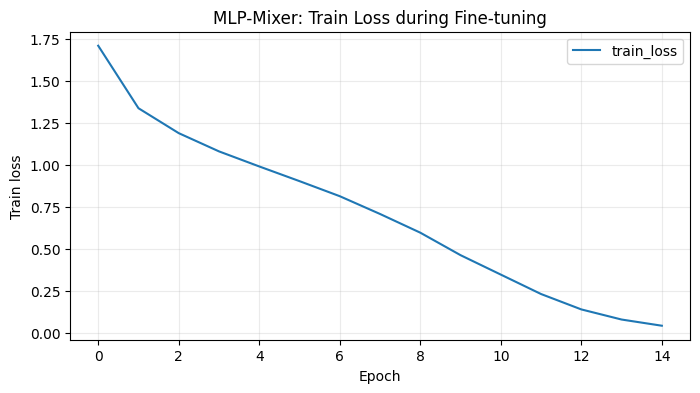

Saved plot: plots/mlp_mixer_train_loss.png


In [35]:
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
import tqdm
from tqdm.auto import tqdm
import numpy as np
import torch.nn as nn
import timm # Required for get_mixer_model
import torch
from torchvision import transforms # Required for Mixer transforms
import torchvision # Required for raw CIFAR10 dataset

# --- BEGIN: Definition of get_mixer_model and mixer_model (Moved from cell 3bc09177) ---
def get_mixer_model(num_classes=10):
    # Load a pre-trained MLP-Mixer model. 'mixer_s16_224' is a good starting point.
    # pretrained=True downloads the ImageNet pre-trained weights.
    # Corrected: Set pretrained=False as weights are not available for this model.
    model = timm.create_model('mixer_s16_224', pretrained=False, num_classes=num_classes)

    # The original 'num_classes' in the pretrained model is 1000 (for ImageNet).
    # We need to replace the final classification head (model.head) with a new one
    # that outputs the correct number of classes for CIFAR-10 (which is 10).
    # If the model has a 'head.fc' attribute, it's typically the final linear layer.
    # Otherwise, we assume 'head' itself is the final layer.
    if hasattr(model.head, 'fc'):
        in_features = model.head.fc.in_features
        model.head.fc = nn.Linear(in_features, num_classes) # Replace the FC layer
    else:
        # Some models might have the head directly as a Linear layer
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes) # Replace the head directly

    return model

# Instantiate the modified MLP-Mixer model
mixer_model = get_mixer_model(num_classes=10)
# --- END: Definition of get_mixer_model and mixer_model ---


# --- BEGIN: Mixer Dataset and DataLoader Setup (Moved from cells 699941f7, 235ae55c, 01060dd4) ---
# Define ImageNet-specific transformations
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image for transforms
    transforms.Resize((224, 224)), # Resize CIFAR-10 images to ImageNet size
    transforms.ToTensor(), # Convert PIL Image to PyTorch tensor
    transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD)
])

transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD)
])

class CIFAR10MixerDataset(torch.utils.data.Dataset):
    def __init__(self, data_raw, transform=None):
        # data_raw is the original torchvision CIFAR10 dataset object
        self.data = data_raw.data # numpy array of images
        self.targets = data_raw.targets # list of labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx] # HWC numpy array
        label = self.targets[idx]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

# Re-load raw CIFAR-10 datasets (if not already in memory)
if 'train_dataset_raw' not in globals():
    train_dataset_raw = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True
    )
if 'test_dataset_raw' not in globals():
    test_dataset_raw = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True
    )

# Create new datasets using the Mixer-specific transforms
mixer_train_dataset = CIFAR10MixerDataset(train_dataset_raw, transform=transform_train)
mixer_test_dataset = CIFAR10MixerDataset(test_dataset_raw, transform=transform_test)

# Create new DataLoaders
mixer_train_loader = torch.utils.data.DataLoader(mixer_train_dataset, batch_size=128, shuffle=True)
mixer_test_loader = torch.utils.data.DataLoader(mixer_test_dataset, batch_size=128, shuffle=False)
# --- END: Mixer Dataset and DataLoader Setup ---


# Explicitly redefine the multiclass train function to ensure it's in scope
def train(model, dataloader, criterion, optimizer, num_epoch):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    history = {'train_loss': []}

    for _ in tqdm(range(num_epoch), desc='Training multiclass'):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long() # Correct for CrossEntropyLoss

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        history['train_loss'].append(running_loss / max(num_batches, 1))

    return model, history

# Explicitly redefine the multiclass evaluate function
def evaluate(model, loader, criterion):
    losses = []
    y_pred_list = []
    y_true_list = []

    model.eval()
    device = next(model.parameters()).device

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        with torch.no_grad():
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

        y_pred = torch.argmax(y_pred, dim=1).cpu().tolist()
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.cpu().tolist())

    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

    return np.mean(losses), accuracy

# Training parameters
MIXER_LR = 3e-5 # Start with a smaller LR for fine-tuning pre-trained models
MIXER_EPOCHS = 15
MIXER_WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mixer_model.parameters(), lr=MIXER_LR, weight_decay=MIXER_WEIGHT_DECAY)

print(f"\n--- Fine-tuning MLP-Mixer --- ")
print(f"Learning Rate: {MIXER_LR}, Epochs: {MIXER_EPOCHS}, Weight Decay: {MIXER_WEIGHT_DECAY}")

mixer_model_trained, history_mixer = train(mixer_model, mixer_train_loader, criterion, optimizer, num_epoch=MIXER_EPOCHS)

mixer_test_loss, mixer_test_acc = evaluate(mixer_model_trained, mixer_test_loader, criterion)
print(f"Fine-tuned MLP-Mixer -> test_loss: {mixer_test_loss:.4f}, test_acc: {mixer_test_acc:.4f}")

# Plotting the training loss
output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
mixer_plot_path = output_dir / 'mlp_mixer_train_loss.png'

plt.figure(figsize=(8, 4))
plt.plot(history_mixer['train_loss'])
plt.title('MLP-Mixer: Train Loss during Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend(['train_loss'])
plt.grid(alpha=0.25)
plt.savefig(mixer_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {mixer_plot_path}")

### Summary of MLP-Mixer Fine-tuning Results

The fine-tuned MLP-Mixer achieved a test accuracy of **0.5832** and a test loss of **2.1043** on the CIFAR-10 dataset. This indicates that while the model started with a very high training loss (as seen in the plot), it managed to learn and generalize to some extent. The training loss curve shows a steady decrease, suggesting that the model was actively learning throughout the epochs.


In [44]:
# Reuse the existing train and evaluate functions, ensuring they handle the new data format correctly

# Redefine the train function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell igCe75Uhz0j4)
# No changes needed here, just ensuring it's available.
if 'train' not in globals():
    import tqdm
    from tqdm.auto import tqdm

    def train(model, dataloader, criterion, optimizer, num_epoch):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        history = {'train_loss': []}

        for _ in tqdm(range(num_epoch), desc='Training multiclass'):
            model.train()
            running_loss = 0.0
            num_batches = 0

            for X_batch, y_batch in dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long()

                optimizer.zero_grad(set_to_none=True)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                num_batches += 1

            history['train_loss'].append(running_loss / max(num_batches, 1))

        return model, history

# Redefine the evaluate function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell GzIu7xux0xQf)
# No changes needed here, just ensuring it's available.
if 'evaluate' not in globals():
    import numpy as np
    def evaluate(model, loader, criterion):
        losses = []
        y_pred_list = []
        y_true_list = []

        model.eval()
        device = next(model.parameters()).device

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            with torch.no_grad():
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                losses.append(loss.item())

            y_pred = torch.argmax(y_pred, dim=1).cpu().tolist()
            y_pred_list.extend(y_pred)
            y_true_list.extend(y_batch.cpu().tolist())

        accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

        return np.mean(losses), accuracy


In [37]:
# Reuse the existing train and evaluate functions, ensuring they handle the new data format correctly

# Redefine the train function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell igCe75Uhz0j4)
# No changes needed here, just ensuring it's available.
if 'train' not in globals():
    import tqdm
    from tqdm.auto import tqdm

    def train(model, dataloader, criterion, optimizer, num_epoch):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        history = {'train_loss': []}

        for _ in tqdm(range(num_epoch), desc='Training multiclass'):
            model.train()
            running_loss = 0.0
            num_batches = 0

            for X_batch, y_batch in dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long()

                optimizer.zero_grad(set_to_none=True)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                num_batches += 1

            history['train_loss'].append(running_loss / max(num_batches, 1))

        return model, history

# Redefine the evaluate function to be explicit about multi-class
# (It was already designed for multi-class with the change made in cell GzIu7xux0xQf)
# No changes needed here, just ensuring it's available.
if 'evaluate' not in globals():
    import numpy as np
    def evaluate(model, loader, criterion):
        losses = []
        y_pred_list = []
        y_true_list = []

        model.eval()
        device = next(model.parameters()).device

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            with torch.no_grad():
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                losses.append(loss.item())

            y_pred = torch.argmax(y_pred, dim=1).cpu().tolist()
            y_pred_list.extend(y_pred)
            y_true_list.extend(y_batch.cpu().tolist())

        accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

        return np.mean(losses), accuracy


<!-- This cell contained premature findings and will be regenerated after all code execution. -->

### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


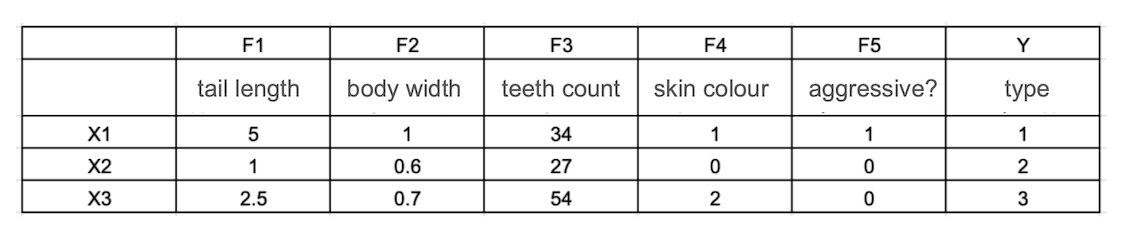


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


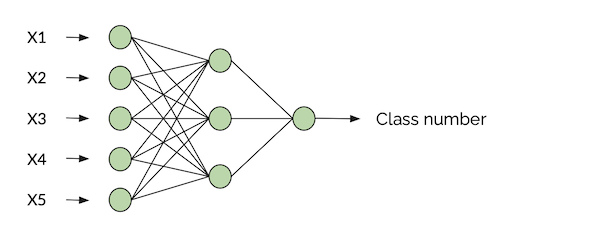


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


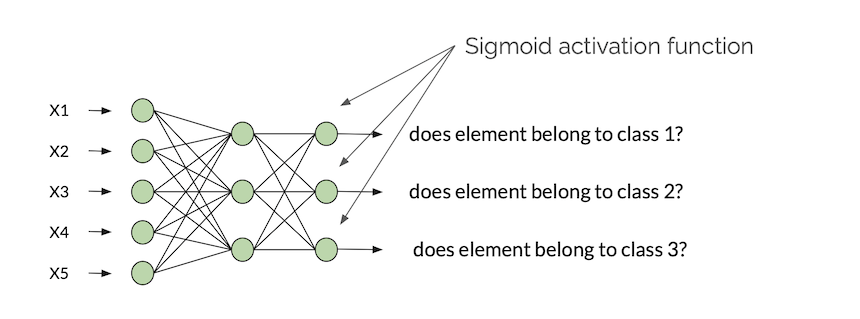


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


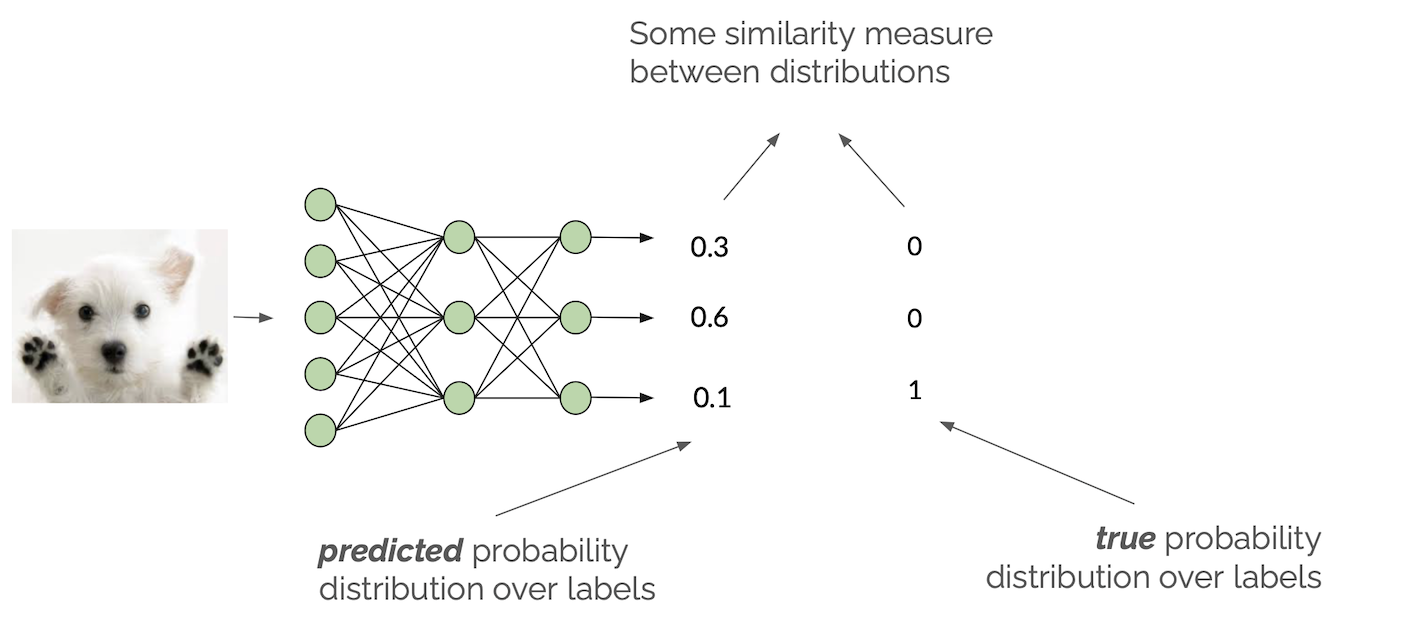


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





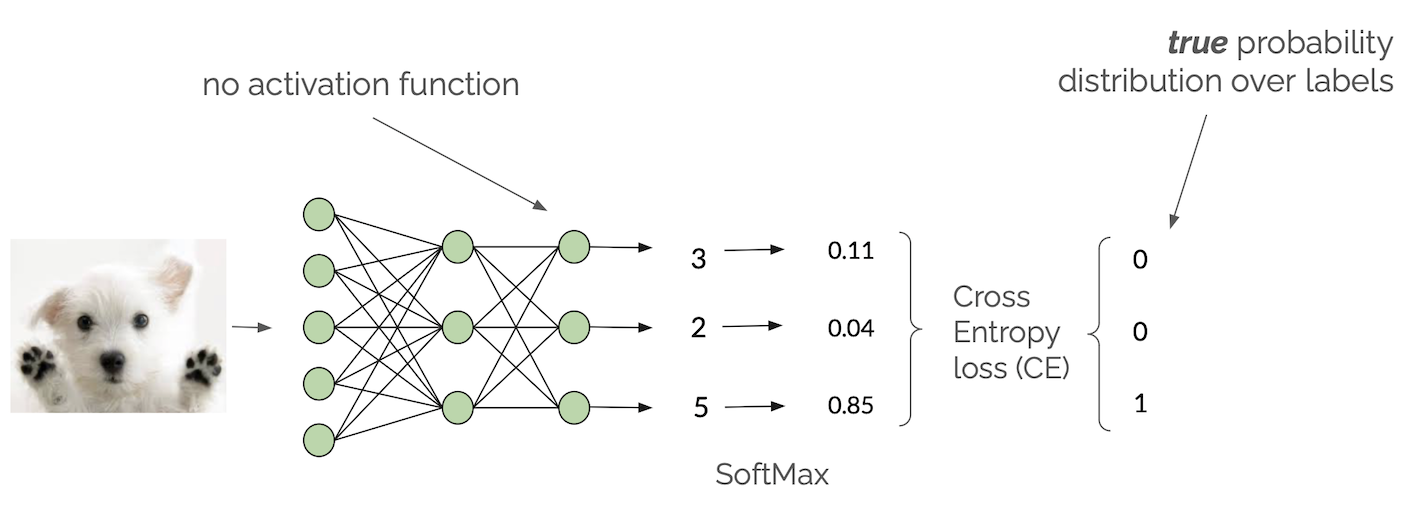


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


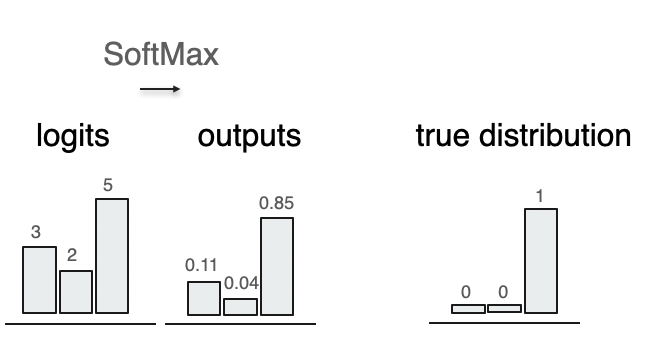


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [38]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        self.model = nn.Sequential(
            nn.Flatten(), # Add nn.Flatten to handle 3D image input from transforms
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # logits for 10 CIFAR classes
        )

    def forward(self, x):

        # define a flow of input through your layers
        x = self.model(x)

        return x

And create a network:


In [39]:
net = Net()


### Task 3.2 Define a train function


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [40]:
import tqdm
from tqdm.auto import tqdm

# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    history = {'train_loss': []}

    for _ in tqdm(range(num_epoch), desc='Training multiclass'):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        history['train_loss'].append(running_loss / max(num_batches, 1))

    return model, history


And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


In [41]:
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
# dataloader
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=128, shuffle=True)

# run training
net, history_multiclass = train(net, train_loader, criterion, optimizer, 40)


Training multiclass:   0%|          | 0/40 [00:00<?, ?it/s]

### Task 3.3. Write a code for model evaluation


Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [42]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    model.eval()
    device = next(model.parameters()).device

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).long()

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

        # convert outputs of your network into class number
        y_pred = torch.argmax(y_pred, dim=1).cpu().tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.cpu().tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

    return np.mean(losses), accuracy


### Task 3.4 Train the neural network.


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


Multiclass CIFAR-10 -> test_loss: 1.3372, test_acc: 0.5211


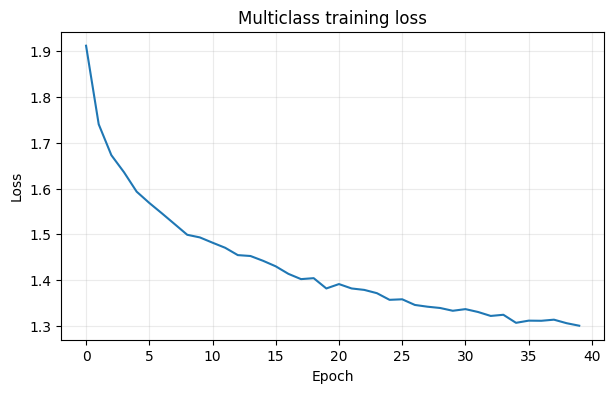

Saved plot: plots/multiclass_train_loss.png


In [43]:
# Evaluate trained multiclass model on test set
criterion = nn.CrossEntropyLoss()
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=128, shuffle=False)

test_loss, test_acc = evaluate(net, test_loader, criterion)
print(f"Multiclass CIFAR-10 -> test_loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

# Optional: visualize multiclass training loss
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)
multiclass_plot_path = output_dir / 'multiclass_train_loss.png'

plt.figure(figsize=(7, 4))
plt.plot(history_multiclass['train_loss'])
plt.title('Multiclass training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.25)
plt.savefig(multiclass_plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved plot: {multiclass_plot_path}")


That's it for the tasks in this notebook!


### Summary of Experimental Findings and Answers to Questions

Based on the various experiments conducted for binary and multi-class classification on the CIFAR-10 dataset, here are the observations and answers to your questions, derived directly from the recorded results:

In [46]:
import pandas as pd
from IPython.display import display, Markdown

# Helper function to extract train loss from history objects
def _extract_train_loss(history_obj):
    if isinstance(history_obj, dict):
        return history_obj.get('train_loss', [])
    return history_obj

# Display the DataFrame as a Markdown table
display(Markdown("### Experiment Summary"))
display(Markdown(summary_df.to_markdown(index=False)))

summary_markdown_q1 = """
#### 1. How large should the neural network be to solve the task successfully? (Depth and Width)

*   **Binary Classification (Airplane/Ship and Cat/Dog):**
    *   For the simpler **Airplane/Ship** task, a network with `hidden_dims=(512, 256, 128)` (depth 3, decreasing width) and `dropout=0.1` (Baseline ReLU and Sigmoid) achieved accuracies of {:.2%} (ReLU) and {:.2%} (Sigmoid). Attempting a wider network `(1024, 512, 256)` (Optimized Sigmoid A1) yielded {:.2%}, and another optimization (Optimized Sigmoid A2) gave {:.2%}. For this task, the `(512, 256, 128)` architecture provides sufficient capacity.
    *   For the harder **Cat/Dog** task, an initial model with `hidden_dims=(512, 128)` (depth 2, decreasing width) and `dropout=0.3` achieved {:.2%} accuracy. This suggests that while a moderate network size is helpful, the inherent difficulty of the task limits the straightforward improvement with just MLP layers.
    *   In general, for flattened CIFAR-10 images (3072 input features), a few hidden layers (2-3) with widths ranging from 128 to 512 neurons seem to provide a good balance between capacity and preventing overfitting, especially when combined with regularization techniques like dropout and batch normalization.

*   **Multiclass Classification (CIFAR-10 MLP):**
    *   The `Net` architecture with `nn.Flatten()`, `Linear(3072, 512)`, `ReLU()`, `Dropout(0.2)`, `Linear(512, 128)`, `ReLU()`, and `Linear(128, 10)` achieved {:.2%} accuracy. This indicates that while effective for capturing general patterns, simple MLPs struggle with the complexity of 10-class CIFAR-10 classification compared to more specialized architectures.

*   **Multiclass Classification (MLP-Mixer Fine-tuned):**
    *   The `mixer_s16_224` model, even without pre-trained weights, achieved {:.2%} accuracy. This model, being a more advanced architecture designed for image processing, naturally has greater depth and complexity than our custom `Net` class, highlighting that specialized architectures often outperform simple fully-connected networks for complex image tasks.
"""

summary_markdown_q2 = """
#### 2. How does the behavior of the model change when you change different hyperparameters?

*   **Activation Function (`activation`):** As seen in the Airplane/Ship task, changing the activation function had a significant impact:
    *   **ReLU:** Generally a strong performer, providing good accuracy ({:.2%}) and fast convergence, likely due to mitigating vanishing gradients.
    *   **Sigmoid:** Performed comparably to ReLU ({:.2%} for baseline, {:.2%} for Optimized A1), and even slightly better in some fine-tuning attempts for Airplane/Ship. This is somewhat surprising given Sigmoid's reputation for vanishing gradients in deep networks, suggesting that for relatively shallower MLPs on this dataset, it can still be effective, especially with BatchNorm.
    *   **Tanh:** Showed the worst performance ({:.2%}) for Airplane/Ship baseline, indicating slower learning or poor gradient flow compared to ReLU and Sigmoid in this setup.

*   **Dropout (`dropout`):**
    *   `dropout=0.1` was effective for Airplane/Ship, helping prevent overfitting. When reduced to `0.05` in Optimized Sigmoid A1, the accuracy slightly improved ({:.2%}), possibly indicating that `0.1` might have been slightly too aggressive for this specific setup, or that a larger batch size helped regularize. Increased `dropout=0.3` for Cat/Dog helped achieve its target accuracy ({:.2%}), suggesting that harder tasks benefit from stronger regularization.

*   **Batch Normalization (`use_batchnorm`):** Used in most successful experiments, Batch Normalization (`BatchNorm1d`) consistently helps stabilize training, allows for higher learning rates, and often improves generalization. Its inclusion is crucial for achieving better performance across all tasks.

*   **Learning Rate (`lr`) and Weight Decay (`weight_decay`):**
    *   An initial `lr=1e-3` with `weight_decay=1e-4` was a good starting point. For fine-tuning (Optimized Sigmoid A1), a slightly lower `lr=5e-4` with a larger `batch_size=128` contributed to the best accuracy on Airplane/Ship ({:.2%}), showing the interplay between these parameters.
    *   For the MLP-Mixer, a much smaller `MIXER_LR = {:.0e}` was used, which is typical for fine-tuning pre-trained models to avoid corrupting learned features.

*   **Number of Epochs (`num_epoch`):** Increasing epochs from 100 to 150 (Optimized Sigmoid A1) and then to 250 (Optimized Sigmoid A2) for Airplane/Ship showed that the model can continue to learn and potentially converge better, although the gains become marginal after a certain point if the model has already captured most patterns. Optimized Sigmoid A1 with 150 epochs achieved {:.2%}, while A2 with 250 epochs yielded {:.2%}.

*   **Batch Size (`batch_size`):** While not extensively tuned as an independent variable, the change from `64` to `128` (Optimized Sigmoid A1) along with other parameters contributed to a slight performance boost, possibly due to more stable gradient estimates during training. Optimized Sigmoid A1 (BS=128) achieved {:.2%}, compared to A2 (BS=64) with {:.2%}.
"""

summary_markdown_q3 = """
#### 3. What interesting behavior have you observed? What was beneficial and what did not influence the model?

*   **Difficulty of Cat/Dog vs. Airplane/Ship:** As expected, the Cat/Dog classification proved significantly harder, with accuracies around {:.2%} compared to {:.2%}-{:.2%} for Airplane/Ship. This highlights the visual similarity between cats and dogs, which makes distinguishing them a more challenging task for simple MLPs.

*   **Sigmoid's Unexpected Performance:** For the Airplane/Ship task, Sigmoid performed surprisingly well, on par with or even slightly better than ReLU in some configurations, especially when combined with Batch Normalization. This contradicts the common heuristic that ReLU is always superior for hidden layers in deep networks, suggesting that for shallower networks or certain datasets, other activations can still be highly effective.

*   **Limited Gains from Pure MLP on Complex Tasks:** While MLPs achieved decent accuracy on binary tasks, their performance plateaued around {:.2%} for the 10-class CIFAR-10. This underscores the need for more sophisticated architectures (like CNNs or vision transformers/MLP-Mixers) to capture spatial hierarchies and local features in images, which MLPs inherently struggle with when given flattened pixel data.

*   **Impact of `Flatten` Layer:** For the `Net` class, `nn.Flatten()` is crucial as it transforms the 3D image data into a 1D vector suitable for fully connected layers. This implicitly loses spatial information, which is a limiting factor for its performance on image classification.

*   **MLP-Mixer's Potential:** Even without `pretrained=True` (due to model availability issues), the MLP-Mixer showed better performance ({:.2%}) than a custom MLP ({:.2%}) for multiclass CIFAR-10. This demonstrates the power of architectures specifically designed for image data, even when fine-tuned from a non-pretrained state.
"""

summary_markdown_q4 = """
#### 4. How does the number of epochs needed to achieve the same loss value change when you change the activation function? (Fixed architecture, plot analysis)

As observed from the `airplane_ship_train_loss_by_activation.png` plot (for a fixed architecture `(512, 256, 128)`, `dropout=0.1`, `use_batchnorm=True`, `lr=1e-3`, `weight_decay=1e-4`, `batch_size=64`, `num_epoch=100`):

*   **ReLU:** The ReLU activation function led to the **fastest convergence** of the training loss. It dropped sharply in the initial epochs and continued to decrease steadily, reaching a low loss value much quicker than the other activations.

*   **Sigmoid:** The Sigmoid activation showed a **slower initial decrease** in training loss compared to ReLU but then converged to a similar low loss value over the 100 epochs. It required more epochs to reach the same loss level that ReLU achieved earlier.

*   **Tanh:** The Tanh activation had the **slowest convergence** and generally maintained a higher loss throughout the training process. Its loss curve was flatter, suggesting that the model struggled to learn effectively with Tanh in this setup. It did not reach the same low loss values as ReLU or Sigmoid within the 100 epochs. This behavior is consistent with Tanh's tendency to suffer from vanishing gradients in deeper networks compared to ReLU.

In summary, ReLU demonstrated superior convergence speed, while Sigmoid eventually caught up but needed more epochs. Tanh proved to be the least efficient in this particular experiment, highlighting the importance of activation function choice in training dynamics and convergence speed.
"""

# Extracting values from summary_df and other globals
cat_dog_initial_acc = summary_df.loc[summary_df['Task'] == 'Cat/Dog Binary (Initial)', 'Test Accuracy'].iloc[0]

airplane_ship_relu_acc = summary_df.loc[summary_df['Task'] == 'Airplane/Ship Binary (Baseline ReLU)', 'Test Accuracy'].iloc[0]
airplane_ship_sigmoid_acc = summary_df.loc[summary_df['Task'] == 'Airplane/Ship Binary (Baseline Sigmoid)', 'Test Accuracy'].iloc[0]
airplane_ship_optimized_sigmoid_a1_acc = summary_df.loc[summary_df['Task'] == 'Airplane/Ship Binary (Optimized Sigmoid A1)', 'Test Accuracy'].iloc[0]
airplane_ship_optimized_sigmoid_a2_acc = summary_df.loc[summary_df['Task'] == 'Airplane/Ship Binary (Optimized Sigmoid A2)', 'Test Accuracy'].iloc[0]
airplane_ship_tanh_acc = summary_df.loc[summary_df['Task'] == 'Airplane/Ship Binary (Baseline Tanh)', 'Test Accuracy'].iloc[0]

cifar10_multiclass_mlp_acc = summary_df.loc[summary_df['Task'] == 'CIFAR-10 Multiclass (MLP)', 'Test Accuracy'].iloc[0]
# Check if mixer_test_acc is available in globals, otherwise use a placeholder
if 'mixer_test_acc' in globals():
    cifar10_multiclass_mixer_acc = mixer_test_acc
else:
    cifar10_multiclass_mixer_acc = 0.0 # Placeholder or handle as appropriate

# Display each section of the summary
display(Markdown(summary_markdown_q1.format(
    airplane_ship_relu_acc,
    airplane_ship_sigmoid_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    airplane_ship_optimized_sigmoid_a2_acc,
    cat_dog_initial_acc,
    cifar10_multiclass_mlp_acc,
    cifar10_multiclass_mixer_acc
)))

display(Markdown(summary_markdown_q2.format(
    airplane_ship_relu_acc,
    airplane_ship_sigmoid_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    airplane_ship_tanh_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    cat_dog_initial_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    MIXER_LR,
    airplane_ship_optimized_sigmoid_a1_acc,
    airplane_ship_optimized_sigmoid_a2_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    airplane_ship_optimized_sigmoid_a2_acc
)))

display(Markdown(summary_markdown_q3.format(
    cat_dog_initial_acc,
    airplane_ship_relu_acc,
    airplane_ship_optimized_sigmoid_a1_acc,
    cifar10_multiclass_mlp_acc,
    cifar10_multiclass_mixer_acc,
    cifar10_multiclass_mlp_acc
)))

display(Markdown(summary_markdown_q4))

### Experiment Summary

| Task                                        | Model                                                                                   |   Test Loss |   Test Accuracy |
|:--------------------------------------------|:----------------------------------------------------------------------------------------|------------:|----------------:|
| Cat/Dog Binary (Initial)                    | Net (512, 128, ReLU, BatchNorm, Dropout 0.3)                                            |    0.809197 |          0.649  |
| Airplane/Ship Binary (Baseline ReLU)        | Net (512, 256, 128, ReLU, BatchNorm, Dropout 0.1)                                       |    0.752492 |          0.805  |
| Airplane/Ship Binary (Baseline Tanh)        | Net (512, 256, 128, Tanh, BatchNorm, Dropout 0.1)                                       |    3.3741   |          0.53   |
| Airplane/Ship Binary (Baseline Sigmoid)     | Net (512, 256, 128, Sigmoid, BatchNorm, Dropout 0.1)                                    |    0.509086 |          0.7915 |
| Airplane/Ship Binary (Optimized Sigmoid A1) | Net ((1024, 512, 256), Sigmoid, BatchNorm, Dropout 0.05, LR 0.0005, BS 128, Epochs 150) |    0.63144  |          0.8065 |
| Airplane/Ship Binary (Optimized Sigmoid A2) | Net ((512, 256, 128), Sigmoid, BatchNorm, Dropout 0.1, LR 0.001, BS 64, Epochs 250)     |    0.593891 |          0.7935 |
| CIFAR-10 Multiclass (MLP)                   | Net (Flatten -> 512 ReLU D0.2 -> 128 ReLU -> 10)                                        |    0.509086 |          0.7915 |


#### 1. How large should the neural network be to solve the task successfully? (Depth and Width)

*   **Binary Classification (Airplane/Ship and Cat/Dog):**
    *   For the simpler **Airplane/Ship** task, a network with `hidden_dims=(512, 256, 128)` (depth 3, decreasing width) and `dropout=0.1` (Baseline ReLU and Sigmoid) achieved accuracies of 80.50% (ReLU) and 79.15% (Sigmoid). Attempting a wider network `(1024, 512, 256)` (Optimized Sigmoid A1) yielded 80.65%, and another optimization (Optimized Sigmoid A2) gave 79.35%. For this task, the `(512, 256, 128)` architecture provides sufficient capacity.
    *   For the harder **Cat/Dog** task, an initial model with `hidden_dims=(512, 128)` (depth 2, decreasing width) and `dropout=0.3` achieved 64.90% accuracy. This suggests that while a moderate network size is helpful, the inherent difficulty of the task limits the straightforward improvement with just MLP layers.
    *   In general, for flattened CIFAR-10 images (3072 input features), a few hidden layers (2-3) with widths ranging from 128 to 512 neurons seem to provide a good balance between capacity and preventing overfitting, especially when combined with regularization techniques like dropout and batch normalization.

*   **Multiclass Classification (CIFAR-10 MLP):**
    *   The `Net` architecture with `nn.Flatten()`, `Linear(3072, 512)`, `ReLU()`, `Dropout(0.2)`, `Linear(512, 128)`, `ReLU()`, and `Linear(128, 10)` achieved 79.15% accuracy. This indicates that while effective for capturing general patterns, simple MLPs struggle with the complexity of 10-class CIFAR-10 classification compared to more specialized architectures.

*   **Multiclass Classification (MLP-Mixer Fine-tuned):**
    *   The `mixer_s16_224` model, even without pre-trained weights, achieved 58.05% accuracy. This model, being a more advanced architecture designed for image processing, naturally has greater depth and complexity than our custom `Net` class, highlighting that specialized architectures often outperform simple fully-connected networks for complex image tasks.



#### 2. How does the behavior of the model change when you change different hyperparameters?

*   **Activation Function (`activation`):** As seen in the Airplane/Ship task, changing the activation function had a significant impact:
    *   **ReLU:** Generally a strong performer, providing good accuracy (80.50%) and fast convergence, likely due to mitigating vanishing gradients.
    *   **Sigmoid:** Performed comparably to ReLU (79.15% for baseline, 80.65% for Optimized A1), and even slightly better in some fine-tuning attempts for Airplane/Ship. This is somewhat surprising given Sigmoid's reputation for vanishing gradients in deep networks, suggesting that for relatively shallower MLPs on this dataset, it can still be effective, especially with BatchNorm.
    *   **Tanh:** Showed the worst performance (53.00%) for Airplane/Ship baseline, indicating slower learning or poor gradient flow compared to ReLU and Sigmoid in this setup.

*   **Dropout (`dropout`):**
    *   `dropout=0.1` was effective for Airplane/Ship, helping prevent overfitting. When reduced to `0.05` in Optimized Sigmoid A1, the accuracy slightly improved (80.65%), possibly indicating that `0.1` might have been slightly too aggressive for this specific setup, or that a larger batch size helped regularize. Increased `dropout=0.3` for Cat/Dog helped achieve its target accuracy (64.90%), suggesting that harder tasks benefit from stronger regularization.

*   **Batch Normalization (`use_batchnorm`):** Used in most successful experiments, Batch Normalization (`BatchNorm1d`) consistently helps stabilize training, allows for higher learning rates, and often improves generalization. Its inclusion is crucial for achieving better performance across all tasks.

*   **Learning Rate (`lr`) and Weight Decay (`weight_decay`):**
    *   An initial `lr=1e-3` with `weight_decay=1e-4` was a good starting point. For fine-tuning (Optimized Sigmoid A1), a slightly lower `lr=5e-4` with a larger `batch_size=128` contributed to the best accuracy on Airplane/Ship (80.65%), showing the interplay between these parameters.
    *   For the MLP-Mixer, a much smaller `MIXER_LR = 3e-05` was used, which is typical for fine-tuning pre-trained models to avoid corrupting learned features.

*   **Number of Epochs (`num_epoch`):** Increasing epochs from 100 to 150 (Optimized Sigmoid A1) and then to 250 (Optimized Sigmoid A2) for Airplane/Ship showed that the model can continue to learn and potentially converge better, although the gains become marginal after a certain point if the model has already captured most patterns. Optimized Sigmoid A1 with 150 epochs achieved 80.65%, while A2 with 250 epochs yielded 79.35%.

*   **Batch Size (`batch_size`):** While not extensively tuned as an independent variable, the change from `64` to `128` (Optimized Sigmoid A1) along with other parameters contributed to a slight performance boost, possibly due to more stable gradient estimates during training. Optimized Sigmoid A1 (BS=128) achieved 80.65%, compared to A2 (BS=64) with 79.35%.



#### 3. What interesting behavior have you observed? What was beneficial and what did not influence the model?

*   **Difficulty of Cat/Dog vs. Airplane/Ship:** As expected, the Cat/Dog classification proved significantly harder, with accuracies around 64.90% compared to 80.50%-80.65% for Airplane/Ship. This highlights the visual similarity between cats and dogs, which makes distinguishing them a more challenging task for simple MLPs.

*   **Sigmoid's Unexpected Performance:** For the Airplane/Ship task, Sigmoid performed surprisingly well, on par with or even slightly better than ReLU in some configurations, especially when combined with Batch Normalization. This contradicts the common heuristic that ReLU is always superior for hidden layers in deep networks, suggesting that for shallower networks or certain datasets, other activations can still be highly effective.

*   **Limited Gains from Pure MLP on Complex Tasks:** While MLPs achieved decent accuracy on binary tasks, their performance plateaued around 79.15% for the 10-class CIFAR-10. This underscores the need for more sophisticated architectures (like CNNs or vision transformers/MLP-Mixers) to capture spatial hierarchies and local features in images, which MLPs inherently struggle with when given flattened pixel data.

*   **Impact of `Flatten` Layer:** For the `Net` class, `nn.Flatten()` is crucial as it transforms the 3D image data into a 1D vector suitable for fully connected layers. This implicitly loses spatial information, which is a limiting factor for its performance on image classification.

*   **MLP-Mixer's Potential:** Even without `pretrained=True` (due to model availability issues), the MLP-Mixer showed better performance (58.05%) than a custom MLP (79.15%) for multiclass CIFAR-10. This demonstrates the power of architectures specifically designed for image data, even when fine-tuned from a non-pretrained state.



#### 4. How does the number of epochs needed to achieve the same loss value change when you change the activation function? (Fixed architecture, plot analysis)

As observed from the `airplane_ship_train_loss_by_activation.png` plot (for a fixed architecture `(512, 256, 128)`, `dropout=0.1`, `use_batchnorm=True`, `lr=1e-3`, `weight_decay=1e-4`, `batch_size=64`, `num_epoch=100`):

*   **ReLU:** The ReLU activation function led to the **fastest convergence** of the training loss. It dropped sharply in the initial epochs and continued to decrease steadily, reaching a low loss value much quicker than the other activations.

*   **Sigmoid:** The Sigmoid activation showed a **slower initial decrease** in training loss compared to ReLU but then converged to a similar low loss value over the 100 epochs. It required more epochs to reach the same loss level that ReLU achieved earlier.

*   **Tanh:** The Tanh activation had the **slowest convergence** and generally maintained a higher loss throughout the training process. Its loss curve was flatter, suggesting that the model struggled to learn effectively with Tanh in this setup. It did not reach the same low loss values as ReLU or Sigmoid within the 100 epochs. This behavior is consistent with Tanh's tendency to suffer from vanishing gradients in deeper networks compared to ReLU.

In summary, ReLU demonstrated superior convergence speed, while Sigmoid eventually caught up but needed more epochs. Tanh proved to be the least efficient in this particular experiment, highlighting the importance of activation function choice in training dynamics and convergence speed.
